In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from google.colab import files
import io

In [ ]:
# Cấu hình hiển thị biểu đồ đẹp hơn
plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.float_format = '{:.4f}'.format

In [ ]:
#LOAD DỮ LIỆU
df = pd.read_excel('/content/DuLieu_TongHop_5Ma.xlsx')
df

,time,FPT,HPG,VCB,BCM,VDS
0,2022-10-11,44.1500,13.2600,34.8600,79.9700,7.0500
1,2022-10-12,45.0200,14.1700,35.9900,82.5900,7.3400
2,2022-10-13,45.3900,14.7700,37.3900,82.5900,7.3400
3,2022-10-14,46.0100,14.7300,38.2900,82.5900,7.5000
4,2022-10-17,45.8900,14.5800,37.2800,81.6200,7.4200
...,...,...,...,...,...,...
780,2025-11-25,98.6700,26.9000,58.2000,65.5000,18.3000
781,2025-11-26,97.9800,27.1000,58.1000,66.4000,18.7000
782,2025-11-27,98.4800,26.9000,57.9000,66.4000,18.5500
783,2025-11-28,96.1000,26.5500,57.4000,66.6000,18.4000


In [ ]:
# Xử lý cột thời gian (Giả sử cột đầu tiên là Time)
col_time = df.columns[0]
df[col_time] = pd.to_datetime(df[col_time])
df.set_index(col_time, inplace=True)

In [ ]:
print("👀 Dữ liệu 5 dòng đầu:")
display(df.head())

👀 Dữ liệu 5 dòng đầu:


,FPT,HPG,VCB,BCM,VDS
time,,,,,
2022-10-11,44.1500,13.2600,34.8600,79.9700,7.0500
2022-10-12,45.0200,14.1700,35.9900,82.5900,7.3400
2022-10-13,45.3900,14.7700,37.3900,82.5900,7.3400
2022-10-14,46.0100,14.7300,38.2900,82.5900,7.5000
2022-10-17,45.8900,14.5800,37.2800,81.6200,7.4200


In [ ]:
# PHẦN 2: TÍNH TOÁN THAM SỐ (LỢI NHUẬN & RỦI RO)
# ==============================================================================
# 1. Tính Tỷ suất sinh lời Logarit (Log Returns)
log_returns = np.log(df / df.shift(1)).dropna()

# 2. Niên hóa số liệu (Giả định 252 phiên/năm)
days = 252
mean_returns = log_returns.mean() * days
cov_matrix = log_returns.cov() * days
std_devs = log_returns.std() * np.sqrt(days)
corr_matrix = log_returns.corr()

print("\n📊 BẢNG THỐNG KÊ MÔ TẢ (NIÊN HÓA):")
stats_df = pd.DataFrame({
    'Lợi nhuận TB (Return)': mean_returns,
    'Độ lệch chuẩn (Risk)': std_devs,
    'Hệ số Sharpe (Giả định)': mean_returns / std_devs
})
display(stats_df.sort_values(by='Lợi nhuận TB (Return)', ascending=False))


📊 BẢNG THỐNG KÊ MÔ TẢ (NIÊN HÓA):


,Lợi nhuận TB (Return),Độ lệch chuẩn (Risk),Hệ số Sharpe (Giả định)
VDS,0.3031,0.4424,0.6851
FPT,0.2517,0.2622,0.9598
HPG,0.2226,0.3257,0.6833
VCB,0.1609,0.2210,0.7279
BCM,-0.0637,0.2812,-0.2264


In [ ]:
# PHẦN 3: TỐI ƯU HÓA DANH MỤC (MARKOWITZ SOLVER)
# ==============================================================================
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, std

def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    p_ret, p_std = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_std

def minimize_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]

num_assets = len(df.columns)
args = (mean_returns, cov_matrix)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0.0, 1.0) for asset in range(num_assets))
init_guess = num_assets * [1. / num_assets,]

In [ ]:
# --- Chạy Solver ---
# 1. Danh mục Tăng trưởng (Max Sharpe)
opt_sharpe = minimize(neg_sharpe_ratio, init_guess, args=(mean_returns, cov_matrix, 0.02),
                      method='SLSQP', bounds=bounds, constraints=constraints)
max_sharpe_ret, max_sharpe_std = portfolio_performance(opt_sharpe.x, mean_returns, cov_matrix)

# 2. Danh mục Phòng thủ (Min Volatility)
opt_vol = minimize(minimize_volatility, init_guess, args=(mean_returns, cov_matrix),
                   method='SLSQP', bounds=bounds, constraints=constraints)
min_vol_ret, min_vol_std = portfolio_performance(opt_vol.x, mean_returns, cov_matrix)

print("\n🏆 KẾT QUẢ TỐI ƯU HÓA:")
results_df = pd.DataFrame({
    'Danh mục': ['Tăng trưởng (Max Sharpe)', 'Phòng thủ (Min Risk)'],
    'Lợi nhuận kỳ vọng': [max_sharpe_ret, min_vol_ret],
    'Rủi ro (Std Dev)': [max_sharpe_std, min_vol_std]
})
for col in df.columns:
    results_df[col] = [opt_sharpe.x[df.columns.get_loc(col)], opt_vol.x[df.columns.get_loc(col)]]

# Định dạng hiển thị phần trăm
# Tạo một dictionary để chỉ định định dạng cho các cột số
format_dict = {col: '{:.2%}' for col in results_df.columns if col != 'Danh mục'}
display(results_df.style.format(format_dict))


🏆 KẾT QUẢ TỐI ƯU HÓA:


,Danh mục,Lợi nhuận kỳ vọng,Rủi ro (Std Dev),FPT,HPG,VCB,BCM,VDS
0,Tăng trưởng (Max Sharpe),23.10%,21.50%,52.80%,5.69%,28.38%,0.00%,13.13%
1,Phòng thủ (Min Risk),13.04%,18.60%,24.02%,1.57%,50.71%,23.69%,0.00%


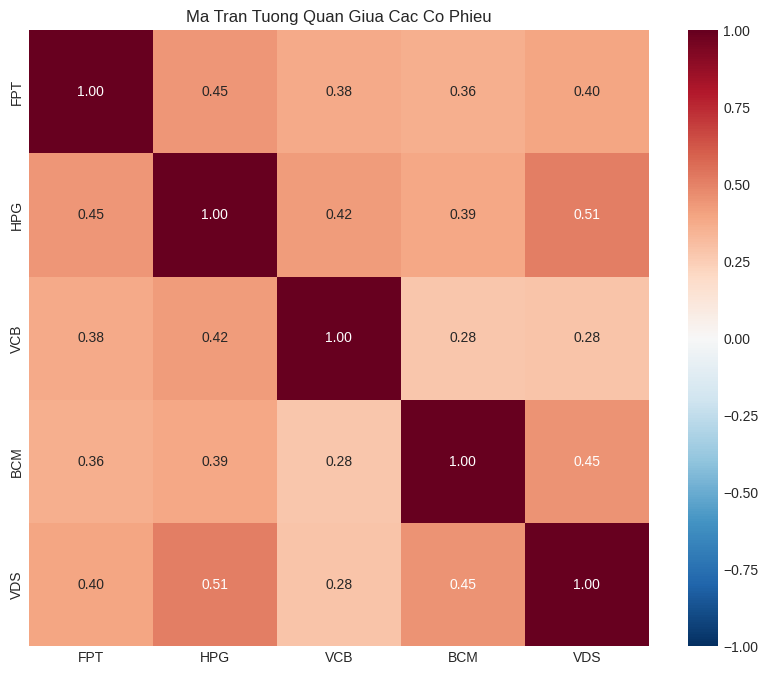

In [ ]:
# PHẦN 4: VẼ BIỂU ĐỒ (VISUALIZATION)
# ==============================================================================

# Biểu đồ 1: Ma trận tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f")
plt.title('Ma Tran Tuong Quan Giua Cac Co Phieu')
plt.show()

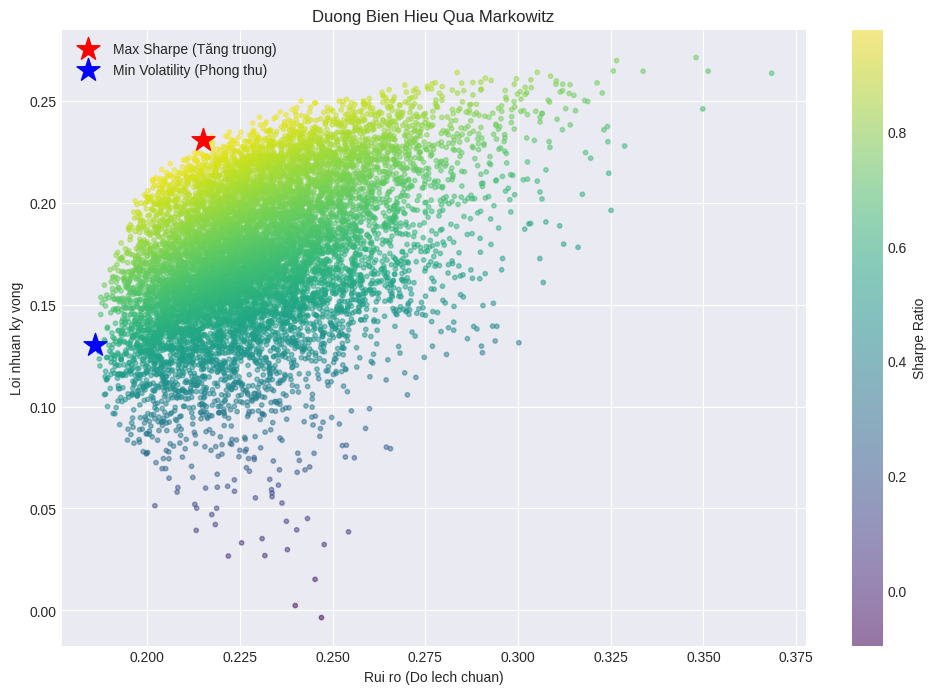

In [ ]:
# Biểu đồ 2: Đường biên hiệu quả
# Mô phỏng 10,000 danh mục ngẫu nhiên
num_ports = 10000
all_weights = np.zeros((num_ports, num_assets))
ret_arr = np.zeros(num_ports)
vol_arr = np.zeros(num_ports)
sharpe_arr = np.zeros(num_ports)

for i in range(num_ports):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    all_weights[i,:] = weights
    ret_arr[i], vol_arr[i] = portfolio_performance(weights, mean_returns, cov_matrix)
    sharpe_arr[i] = (ret_arr[i] - 0.02) / vol_arr[i]

plt.figure(figsize=(12, 8))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', s=10, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(max_sharpe_std, max_sharpe_ret, marker='*', color='red', s=300, label='Max Sharpe (Tăng truong)')
plt.scatter(min_vol_std, min_vol_ret, marker='*', color='blue', s=300, label='Min Volatility (Phong thu)')
plt.title('Duong Bien Hieu Qua Markowitz')
plt.xlabel('Rui ro (Do lech chuan)')
plt.ylabel('Loi nhuan ky vong')
plt.legend()
plt.show()

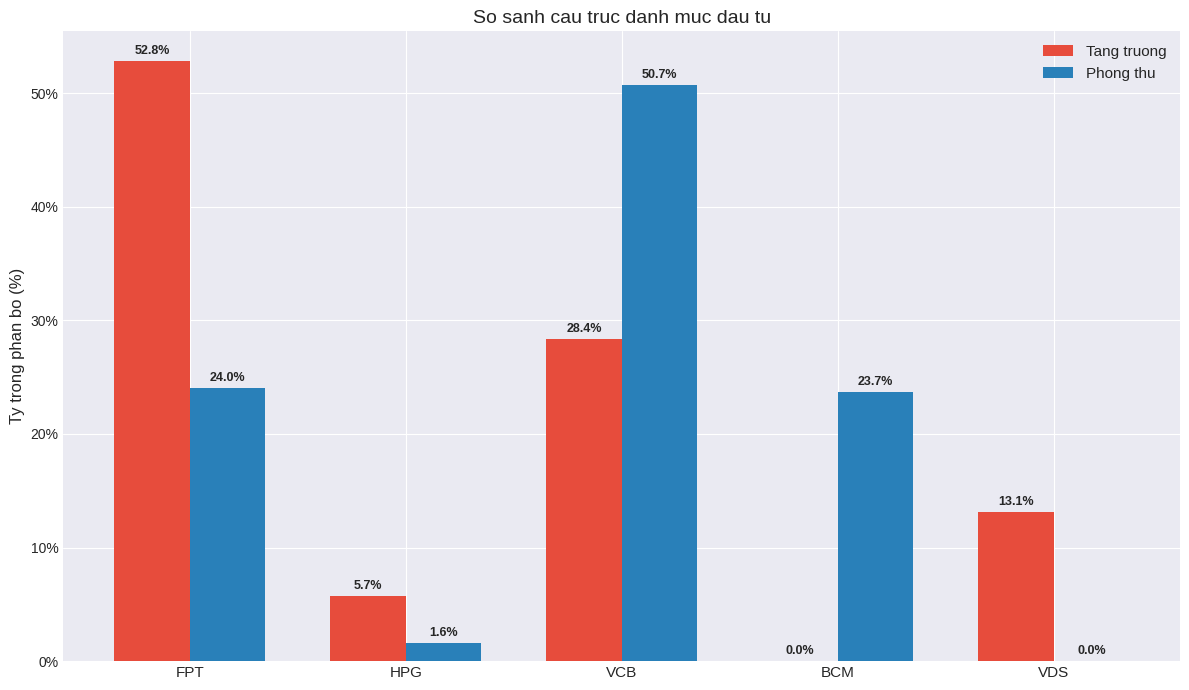

In [ ]:
import matplotlib.ticker as mtick

# --- Biểu đồ 3: So sánh Tỷ trọng (CÓ SỐ LIỆU NHỎ TRÊN CỘT) ---
x = np.arange(num_assets)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))

# Vẽ cột (Nhân 100 để ra %)
rects1 = ax.bar(x - width/2, opt_sharpe.x * 100, width, label='Tang truong', color='#e74c3c')
rects2 = ax.bar(x + width/2, opt_vol.x * 100, width, label='Phong thu', color='#2980b9')

ax.set_ylabel('Ty trong phan bo (%)', fontsize=12)
ax.set_title('So sanh cau truc danh muc dau tu', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df.columns, fontsize=11)
ax.legend(fontsize=11)

# Định dạng trục Y thành %
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# THÊM NHÃN SỐ LIỆU (Cái bạn cần đây nè)
ax.bar_label(rects1, padding=3, fmt='%.1f%%', fontsize=9, fontweight='bold')
ax.bar_label(rects2, padding=3, fmt='%.1f%%', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



In [ ]:
# ==============================================================================
# PHẦN BỔ SUNG: BẢNG SỐ LIỆU TỶ SUẤT SINH LỜI CHI TIẾT
# ==============================================================================

# 1. TÍNH LỢI NHUẬN TỪNG NĂM (YEARLY RETURNS)
# Lấy giá đóng cửa ngày cuối cùng của mỗi năm
yearly_prices = df.resample('YE').last()
# Thêm giá ngày đầu tiên vào để tính cho năm đầu tiên (2022)
yearly_prices = pd.concat([df.iloc[:1], yearly_prices])
# Tính % thay đổi giữa các năm
yearly_returns = yearly_prices.pct_change().dropna()
# Đổi tên index chỉ lấy năm cho gọn (ví dụ: 2023, 2024)
yearly_returns.index = yearly_returns.index.year

print("\n📅 BẢNG TỶ SUẤT SINH LỜI QUA TỪNG NĂM (%)")
# Tô màu: Xanh lá nếu dương, Đỏ nếu âm để dễ nhìn
display(yearly_returns.style.format("{:.2%}")
        .background_gradient(cmap='RdYlGn', vmin=-0.5, vmax=0.5))

# 2. TÍNH CÁC CHỈ SỐ HIỆU QUẢ ĐẦU TƯ (PERFORMANCE METRICS)
# - Lợi nhuận tích lũy (Total Return): Lãi bao nhiêu từ ngày đầu đến ngày cuối
total_return = (df.iloc[-1] / df.iloc[0]) - 1

# - Độ sụt giảm tối đa (Max Drawdown): Mức lỗ nặng nhất từng gánh chịu từ đỉnh
rolling_max = df.cummax()
daily_drawdown = df / rolling_max - 1.0
max_drawdown = daily_drawdown.min()

# Tổng hợp vào một bảng
performance_df = pd.DataFrame({
    'Lợi nhuận Tích lũy (Total Return)': total_return,
    'Lợi nhuận TB Năm (Ann. Return)': mean_returns, # Đã tính ở phần trước
    'Rủi ro (Ann. Volatility)': std_devs,           # Đã tính ở phần trước
    'Sụt giảm sâu nhất (Max Drawdown)': max_drawdown
})

print("\n📊 BẢNG TỔNG HỢP HIỆU QUẢ & RỦI RO (%)")
display(performance_df.style.format("{:.2%}")
        .background_gradient(cmap='Blues', subset=['Lợi nhuận Tích lũy (Total Return)', 'Lợi nhuận TB Năm (Ann. Return)'])
        .background_gradient(cmap='Reds_r', subset=['Sụt giảm sâu nhất (Max Drawdown)'])) # Reds_r: Đỏ đậm là xấu (lỗ sâu)

print("\n👉 Giải thích:")
print("- Yearly Return: Cho biết từng năm cụ thể mã đó lãi/lỗ bao nhiêu.")
print("- Max Drawdown: Cho biết rủi ro 'đu đỉnh', ví dụ -30% nghĩa là từng có lúc giá giảm 30% từ đỉnh cao nhất.")


📅 BẢNG TỶ SUẤT SINH LỜI QUA TỪNG NĂM (%)


,FPT,HPG,VCB,BCM,VDS
time,,,,,
2022,8.31%,2.87%,29.03%,-2.06%,-15.18%
2023,47.07%,55.21%,18.56%,-20.89%,133.11%
2024,85.03%,4.91%,13.56%,14.43%,36.30%
2025,-25.77%,19.32%,-5.05%,-7.48%,-4.74%



📊 BẢNG TỔNG HỢP HIỆU QUẢ & RỦI RO (%)


,Lợi nhuận Tích lũy (Total Return),Lợi nhuận TB Năm (Ann. Return),Rủi ro (Ann. Volatility),Sụt giảm sâu nhất (Max Drawdown)
FPT,118.80%,25.17%,26.22%,-34.61%
HPG,99.85%,22.26%,32.57%,-37.91%
VCB,64.95%,16.09%,22.10%,-22.00%
BCM,-17.97%,-6.37%,28.12%,-40.48%
VDS,156.74%,30.31%,44.24%,-45.28%



👉 Giải thích:
- Yearly Return: Cho biết từng năm cụ thể mã đó lãi/lỗ bao nhiêu.
- Max Drawdown: Cho biết rủi ro 'đu đỉnh', ví dụ -30% nghĩa là từng có lúc giá giảm 30% từ đỉnh cao nhất.


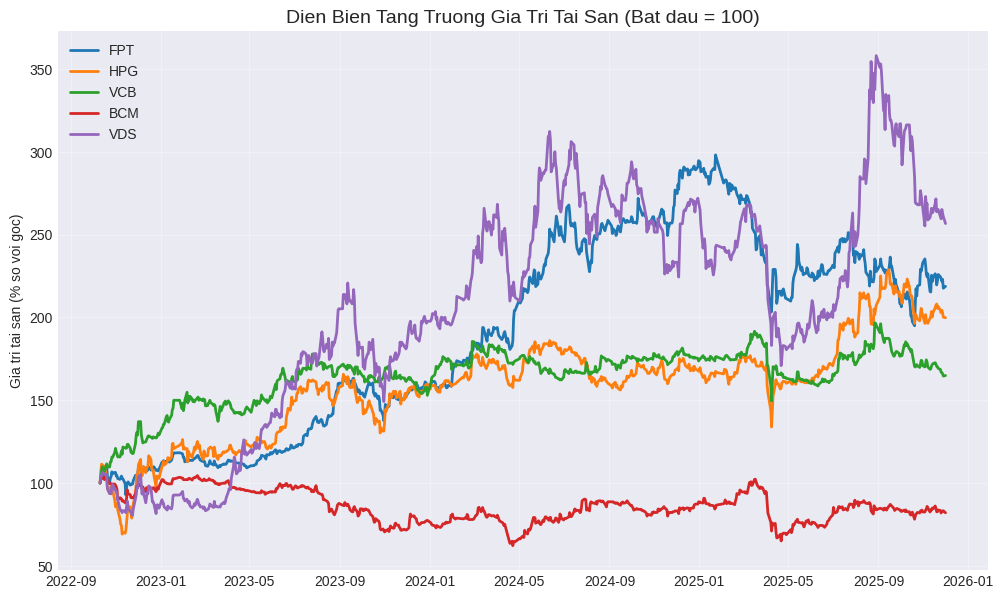

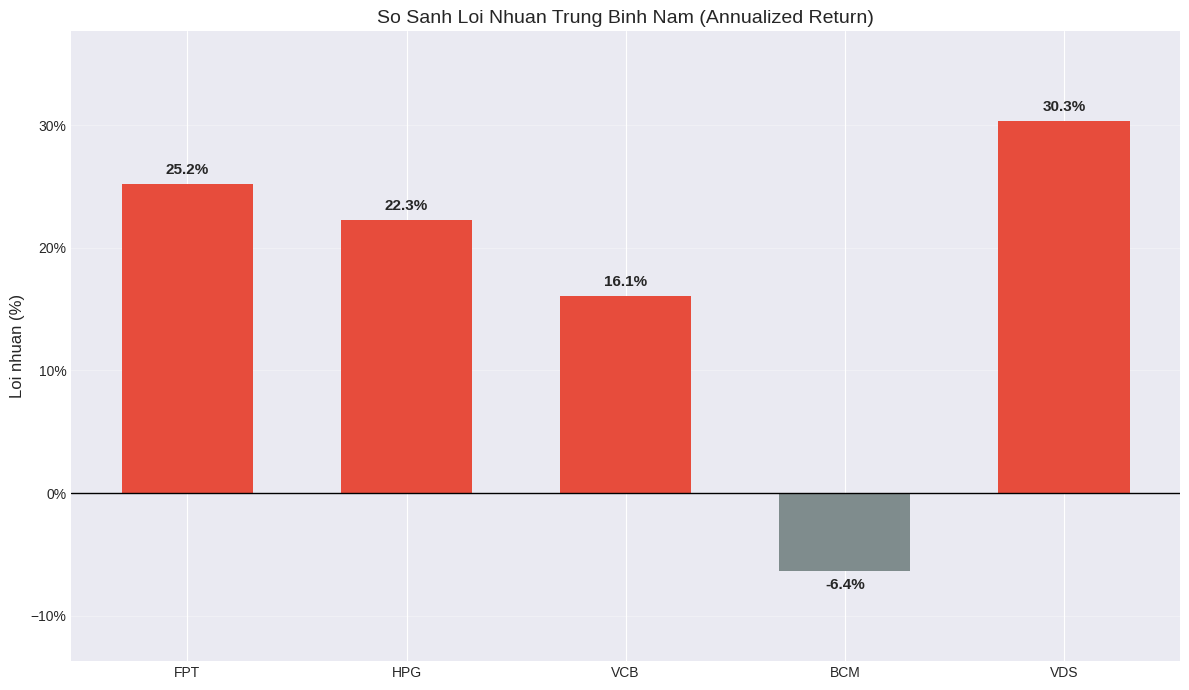

In [ ]:
# ==============================================================================
# PHẦN BỔ SUNG: BIỂU ĐỒ TỶ SUẤT SINH LỜI (ĐÃ FIX LỖI SỐ BỊ ĐÈ)
# ==============================================================================
import matplotlib.ticker as mtick

# --- BIỂU ĐỒ 4: DIỄN BIẾN TĂNG TRƯỞNG TÀI SẢN (Cumulative Returns) ---
# Giả sử ban đầu đầu tư 100 đồng vào mỗi mã
normalized_price = (df / df.iloc[0]) * 100

plt.figure(figsize=(12, 7))
for col in df.columns:
    plt.plot(normalized_price.index, normalized_price[col], label=col, linewidth=2)

plt.title('Dien Bien Tang Truong Gia Tri Tai San (Bat dau = 100)', fontsize=14)
plt.ylabel('Gia tri tai san (% so voi goc)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# --- BIỂU ĐỒ 5: SO SÁNH LỢI NHUẬN TRUNG BÌNH NĂM (Annualized Return) ---
# Lấy số liệu Lợi nhuận TB đổi ra %
mean_returns_pct = mean_returns * 100

fig, ax = plt.subplots(figsize=(12, 7))

# Vẽ cột: Màu đỏ nếu dương, Màu xám nếu âm
colors = ['#e74c3c' if x >= 0 else '#7f8c8d' for x in mean_returns_pct]
bars = ax.bar(mean_returns_pct.index, mean_returns_pct, color=colors, width=0.6)

plt.title('So Sanh Loi Nhuan Trung Binh Nam (Annualized Return)', fontsize=14)
plt.ylabel('Loi nhuan (%)', fontsize=12)

# Kẻ đường ngang mốc 0 cho dễ nhìn
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)

# Định dạng trục Y thành số %
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# --- FIX LỖI SỐ BỊ ĐÈ ---
# 1. Nới rộng khoảng cách trần và sàn của biểu đồ thêm 20% để lấy chỗ viết số
ax.margins(y=0.2)

# 2. Dùng bar_label để tự động gắn số
# padding=3: Cách đầu cột 3 điểm ảnh
# labels: Định dạng số có 1 chữ số thập phân kèm dấu %
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

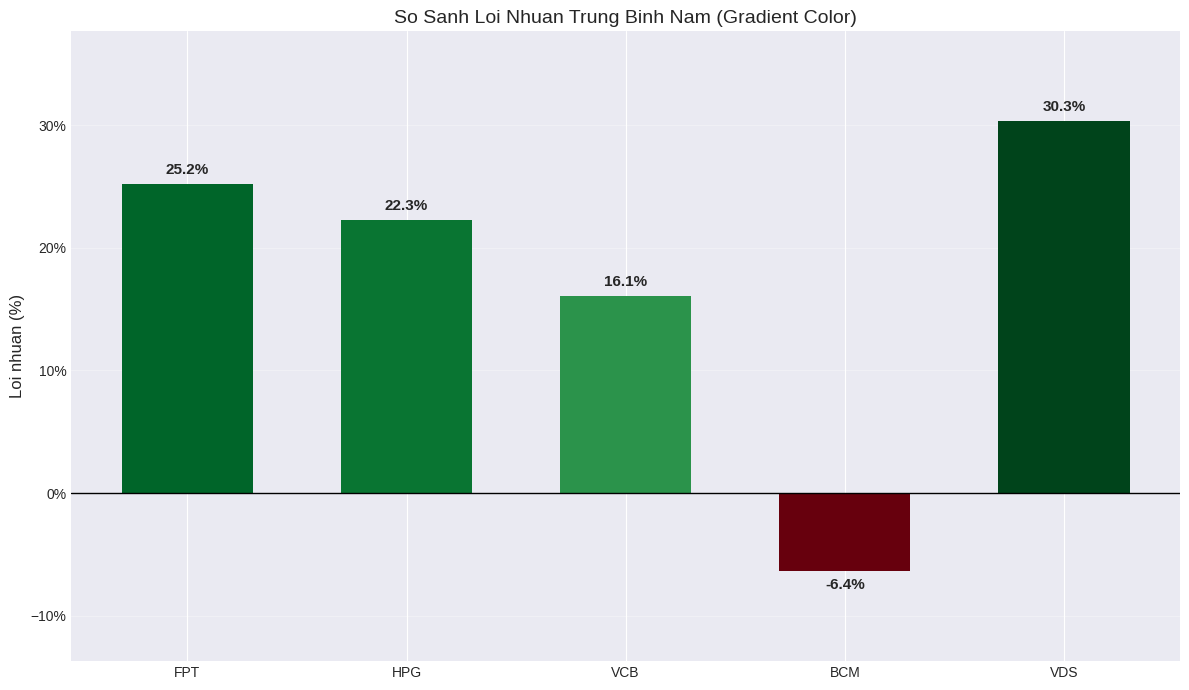

In [ ]:
# ==============================================================================
# PHẦN VẼ BIỂU ĐỒ MÀU GRADIENT (ĐẬM NHẠT THEO GIÁ TRỊ)
# ==============================================================================
import matplotlib.cm as cm # Thư viện bảng màu
import matplotlib.colors as mcolors

# Lấy số liệu Lợi nhuận TB đổi ra %
mean_returns_pct = mean_returns * 100

fig, ax = plt.subplots(figsize=(12, 7))

# --- XỬ LÝ MÀU SẮC THÔNG MINH ---
# Tìm giá trị lớn nhất (để làm chuẩn cho màu đậm nhất)
max_pos = max(mean_returns_pct.max(), 0.1) # Tránh lỗi chia cho 0
min_neg = min(mean_returns_pct.min(), -0.1)

custom_colors = []
for val in mean_returns_pct:
    if val >= 0:
        # Nếu Dương: Dùng bảng màu Xanh lá (Greens)
        # Công thức: 0.4 (độ đậm tối thiểu) + tỷ lệ % độ đậm
        intensity = 0.4 + 0.6 * (val / max_pos)
        custom_colors.append(cm.Greens(intensity))
    else:
        # Nếu Âm: Dùng bảng màu Đỏ (Reds)
        intensity = 0.4 + 0.6 * (abs(val) / abs(min_neg))
        custom_colors.append(cm.Reds(intensity))

# Vẽ cột với danh sách màu vừa tạo
bars = ax.bar(mean_returns_pct.index, mean_returns_pct, color=custom_colors, width=0.6)

# --- CÁC THIẾT LẬP KHÁC (Giữ nguyên cho đẹp) ---
plt.title('So Sanh Loi Nhuan Trung Binh Nam (Gradient Color)', fontsize=14)
plt.ylabel('Loi nhuan (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.margins(y=0.2)

# Gắn số liệu lên đầu cột
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CẬP NHẬT: TÍNH BẢNG THỐNG KÊ MÔ TẢ (CÓ SHARPE CHUẨN)
# ==============================================================================

# 1. Các tham số đầu vào
risk_free_rate = 0.02 # Giả định lãi suất phi rủi ro là 2% (Trái phiếu CP)
days = 252

# 2. Tính toán
log_returns = np.log(df / df.shift(1)).dropna()
mean_returns = log_returns.mean() * days
std_devs = log_returns.std() * np.sqrt(days)

# Tính Sharpe Ratio chuẩn: (Lợi nhuận - Lãi suất phi rủi ro) / Rủi ro
sharpe_ratios = (mean_returns - risk_free_rate) / std_devs

# 3. Tạo bảng hiển thị đẹp
stats_df = pd.DataFrame({
    'Lợi nhuận (Return)': mean_returns,
    'Rủi ro (Volatility)': std_devs,
    'Hệ số Sharpe': sharpe_ratios
})

print("\n📊 BẢNG 3.1: THỐNG KÊ MÔ TẢ & HIỆU QUẢ ĐẦU TƯ")
display(stats_df.sort_values(by='Hệ số Sharpe', ascending=False)
        .style.format({
            'Lợi nhuận (Return)': '{:.2%}',
            'Rủi ro (Volatility)': '{:.2%}',
            'Hệ số Sharpe': '{:.2f}'
        })
        .background_gradient(cmap='RdYlGn', subset=['Hệ số Sharpe'], vmin=0, vmax=1))

print(f"\n👉 Ghi chú: Hệ số Sharpe được tính với lãi suất phi rủi ro (Risk-Free Rate) = {risk_free_rate:.0%}")


📊 BẢNG 3.1: THỐNG KÊ MÔ TẢ & HIỆU QUẢ ĐẦU TƯ


,Lợi nhuận (Return),Rủi ro (Volatility),Hệ số Sharpe
FPT,25.17%,26.22%,0.88
VDS,30.31%,44.24%,0.64
VCB,16.09%,22.10%,0.64
HPG,22.26%,32.57%,0.62
BCM,-6.37%,28.12%,-0.30



👉 Ghi chú: Hệ số Sharpe được tính với lãi suất phi rủi ro (Risk-Free Rate) = 2%


In [ ]:
# ==============================================================================
# PHẦN TÍNH HỆ SỐ SHARPE (Risk-Free Rate = Bond Yield)
# ==============================================================================
import pandas as pd
import numpy as np

# 1. THIẾT LẬP LÃI SUẤT PHI RỦI RO (RISK-FREE RATE)
# Lấy theo Lợi suất Trái phiếu Chính phủ VN kỳ hạn 10 năm (Giả định hiện tại ~2.7%)
risk_free_rate = 0.027

# 2. TÍNH TOÁN CÁC THAM SỐ CƠ BẢN (Nếu chưa tính ở trên)
# (Đảm bảo biến df đã được load từ các bước trước)
days = 252
log_returns = np.log(df / df.shift(1)).dropna()

# Lợi nhuận kỳ vọng (Annualized Return)
mean_returns = log_returns.mean() * days
# Rủi ro (Annualized Volatility)
std_devs = log_returns.std() * np.sqrt(days)

# 3. TÍNH HỆ SỐ SHARPE
# Công thức: (Lợi nhuận cổ phiếu - Lãi suất phi rủi ro) / Rủi ro cổ phiếu
sharpe_ratios = (mean_returns - risk_free_rate) / std_devs

# 4. HIỂN THỊ BẢNG KẾT QUẢ
sharpe_df = pd.DataFrame({
    'Lợi nhuận kỳ vọng (Return)': mean_returns,
    'Rủi ro (Volatility)': std_devs,
    'Hệ số Sharpe': sharpe_ratios
})

print(f"\n📊 BẢNG ĐÁNH GIÁ HIỆU QUẢ ĐẦU TƯ (Với lãi suất phi rủi ro Rf = {risk_free_rate:.1%})")
print("-" * 80)

# Sắp xếp từ cao xuống thấp để thấy mã nào hiệu quả nhất
# Tô màu cột Sharpe: Xanh đậm (Tốt) -> Đỏ (Kém)
display(sharpe_df.sort_values(by='Hệ số Sharpe', ascending=False)
        .style.format({
            'Lợi nhuận kỳ vọng (Return)': '{:.2%}',
            'Rủi ro (Volatility)': '{:.2%}',
            'Hệ số Sharpe': '{:.2f}'
        })
        .background_gradient(cmap='RdYlGn', subset=['Hệ số Sharpe'], vmin=0, vmax=1))

print("\n👉 NHẬN XÉT NHANH:")
print(f"1. Cổ phiếu có Sharpe cao nhất là mã đáng đầu tư nhất (vì 1 đồng rủi ro sinh ra nhiều đồng lời nhất).")
print(f"2. Nếu Sharpe < 0: Cổ phiếu này đang kém hiệu quả hơn cả việc đi mua Trái phiếu Chính phủ ({risk_free_rate:.1%}/năm).")


📊 BẢNG ĐÁNH GIÁ HIỆU QUẢ ĐẦU TƯ (Với lãi suất phi rủi ro Rf = 2.7%)
--------------------------------------------------------------------------------


,Lợi nhuận kỳ vọng (Return),Rủi ro (Volatility),Hệ số Sharpe
FPT,25.17%,26.22%,0.86
VDS,30.31%,44.24%,0.62
VCB,16.09%,22.10%,0.61
HPG,22.26%,32.57%,0.60
BCM,-6.37%,28.12%,-0.32



👉 NHẬN XÉT NHANH:
1. Cổ phiếu có Sharpe cao nhất là mã đáng đầu tư nhất (vì 1 đồng rủi ro sinh ra nhiều đồng lời nhất).
2. Nếu Sharpe < 0: Cổ phiếu này đang kém hiệu quả hơn cả việc đi mua Trái phiếu Chính phủ (2.7%/năm).
